In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, make_scorer
from sklearn.metrics import precision_score, recall_score, f1_score
import xgboost as xgb
import shap
import pyreadstat
from sklearn.utils import resample
from dcurves import dca, plot_graphs

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

## 1. DATA LOADING & INITIAL CLEANING

In [24]:
file_path = "data/DB_ML_DOPPIA_BIOPSIA.sav" 
df, meta = pyreadstat.read_sav(file_path)

# Combine baseline status
df['Baseline_HER2_status'] = df['Biopsy1_HER2_status'].combine_first(df['PrimaryBC_HER2_status'])

# Drop useless columns
df.drop(['Biopsy1_HER2_status', 'PrimaryBC_HER2_status', 'Codice_pz', 'Year_diagnosis', 'Year_meta'], axis=1, inplace=True)
df.dropna(subset=['Baseline_HER2_status', 'Biopsy2_HER2_status'], inplace=True)

# Create outcome variable: 1 (Switch), 0 (No Switch), 2 (Other)
df['Switch_HER2_status'] = np.where((df['Baseline_HER2_status'] == 1) & (df['Biopsy2_HER2_status'] == 2), 1,
                                   np.where((df['Baseline_HER2_status'] == 1) & (df['Biopsy2_HER2_status'] == 1), 0, 2))

# Drop Class 2 (Other) to frame as binary classification (0 vs 1)
df.drop(df[df['Switch_HER2_status'] == 2].index, inplace=True)
df['Switch_HER2_status'] = df['Switch_HER2_status'].astype('int')

# Drop target source columns
df.drop(['Baseline_HER2_status', 'Biopsy2_HER2_status'], axis=1, inplace=True)

# make categorical variables categorical
categorical_vars = [
  'Age_diagnosis_years_50cutoff', 'Neoadj_CT', 'PrimaryBC_histo_CDI_vs_other', 'PrimaryBC_grade_G1.2_vs_G3',
  'PrimaryBC_phenotype_TNBC_vs_other', 'PrimaryBC_phenotype_Luminal_vs_other', 'PrimaryBC_phenotype_HER2pos_vs_other',
  'PrimaryBC_stageIVatdiagnosis', 'Adj_CT', 'Adj_ET', 'Relapse_first_local',
  'Relapse_first_distant', 'Relapse_first_distant_visceral_incl_pleura_peritoneo',
  'Relapse_first_distant_lymphnodes', 'Relapse_first_distant_softskin', 'Relapse_first_distant_bone',
  'Relapse_first_distant_liver', 'Relapse_first_distant_lung', 'Relapse_first_distant_brain',
  'Relapse_first_distant_unusual', 'Biopsy1_site_lymphnode', 'Biopsy1_site_softskin', 'Biopsy1_site_bone',
  'Biopsy1_site_liver', 'Biopsy1_site_lung', 'Biopsy1_site_brain', 'Biopsy1_site_other',
  'Biopsy1_phenotype_tnbc_vs_other', 'Biopsy1_phenotype_luminal_vs_other',
  'Biopsy1_phenotype_her2pos_vs_other', 'Biopsy2_si_no', 'Biopsy2_site_lymphnode', 'Biopsy2_site_softskin',
  'Biopsy2_site_bone', 'Biopsy2_site_liver', 'Biopsy2_site_lung', 'Biopsy2_site_brain', 'Biopsy2_site_other',
  'Biopsy2_phenotype_tnbc_vs_other', 'Biopsy2_phenotype_luminal_vs_other',
  'Biopsy2_phenotype_her2pos_vs_other', 'MBCtherapy_CT', 'MBCtherapy_antiHER2', 'MBCtherapy_ET',
  'MBCtherapy_CDK4_6'
]

# check all categorical variables are in df
for var in categorical_vars:
    if var not in df.columns:
        print(f"Variable {var} not found in DataFrame")

df[categorical_vars] = df[categorical_vars].astype('category')

# create numerical_vars
numeric_vars = df.select_dtypes(include=['float', 'int']).columns

df['Switch_HER2_status'].value_counts()

Switch_HER2_status
0    83
1    39
Name: count, dtype: int64

## 2. DROP FUTURE DATA
Drop all Biopsy2 columns before feature selection or modeling

In [25]:
biopsy2_cols = df.filter(like='Biopsy2').columns
df.drop(columns=biopsy2_cols, inplace=True)

## 3. APPLY DOMAIN-SPECIFIC CUTOFFS

In [26]:
cutoffs = {
    'PrimaryBC_ER': [10, 50, 80],
    'PrimaryBC_PgR': [20],
    'Biopsy1_ER': [10, 50, 80],
    'Biopsy1_PgR': [20],
    'Time_fromdiagnosis_to_firstbiopsy': [24, 60],
    'Time_from_relapse_to_firstbiopsy': [0, 12, 24],
    'Time_from_firstbiopsy_to_secondbiopsy': [6, 12, 24]
}

new_binary_vars = []
for var, thresholds in cutoffs.items():
    for cutoff in thresholds:
        new_col = f"{var}_over_{cutoff}"
        if var in df.columns:
            df[new_col] = (df[var] >= cutoff).astype(int) # Use int for binary flags
            new_binary_vars.append(new_col)
    
    if var in df.columns:
        df.drop(var, axis=1, inplace=True)

## 4. DEFINE FEATURES & TARGET

In [27]:
target_col = "Switch_HER2_status"
X = df.drop(columns=[target_col])
y = df[target_col]

# Identify Categorical vs Numerical
categorical_vars = X.select_dtypes(include=['category', 'object']).columns.tolist()
categorical_vars.extend(new_binary_vars)

# Everything else is numeric
numeric_vars = [col for col in X.columns if col not in categorical_vars]

# Convert strings/categories to string type for the imputer
X[categorical_vars] = X[categorical_vars].astype(str)

## 5. TRAIN-TEST SPLIT
Split is stratified due to imbalance

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.4, random_state=42
)

## 6. BUILD THE PIPELINE
Only training set will be processed to prevent data leakage

In [29]:
# Numeric pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', IterativeImputer(random_state=42, max_iter=10)),
    ('scaler', StandardScaler())
])

# Categorical pipeline
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_vars),
    ('cat', categorical_transformer, categorical_vars)
])

# Feature selection
feature_selector = SelectFromModel(
    LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced', random_state=42)
)

# Actual classifier
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum() # Handles 2:1 imbalance
classifier = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    max_depth=2,           
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=5
)

# Full pipeline all together
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('feature_selection', feature_selector),
    ('classifier', classifier)
])

## 7. GRID SEARCH CROSS-VALIDATION

In [30]:
# Define custom scorer penalizing False Negatives
def penalize_fn_score(y_true, y_pred, fn_weight=5):
    cm = confusion_matrix(y_true, y_pred)
    # Handle cases where classes might be missing in a fold
    if cm.shape == (1, 1):
        return 0.0
    tn, fp, fn, tp = cm.ravel()
    penalty = fn_weight * fn + fp
    score = 1 - penalty / (tp + fn + fp + tn)
    return score

fn_scorer = make_scorer(penalize_fn_score, greater_is_better=True)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
param_grid = {
    'feature_selection__estimator__C': [0.1, 0.25, 0.5, 0.75, 1.0, 5.0, 10.0],
    'classifier__n_estimators': [50, 100, 150, 200, 250]
}

grid = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    scoring=fn_scorer, 
    cv=cv,
    n_jobs=-1
)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__n_estimators': [50, 100, ...], 'feature_selection__estimator__C': [0.1, 0.25, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",make_scorer(p...hod='predict')
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation t

## 8. EVALUATION
Confusion matrix on the best model selected out of the grid

In [31]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print("Best Parameters:", grid.best_params_)
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=["No Switch", "Switch"]))

Best Parameters: {'classifier__n_estimators': 150, 'feature_selection__estimator__C': 0.5}

Classification Report:
               precision    recall  f1-score   support

   No Switch       0.81      0.67      0.73        33
      Switch       0.50      0.69      0.58        16

    accuracy                           0.67        49
   macro avg       0.66      0.68      0.66        49
weighted avg       0.71      0.67      0.68        49



## 9. SHAP EXPLAINABILITY ON TEST SET

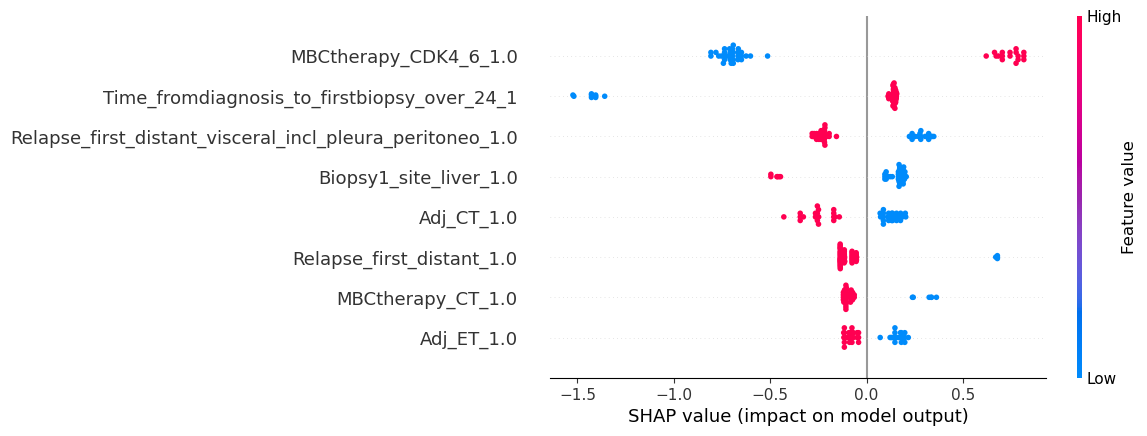

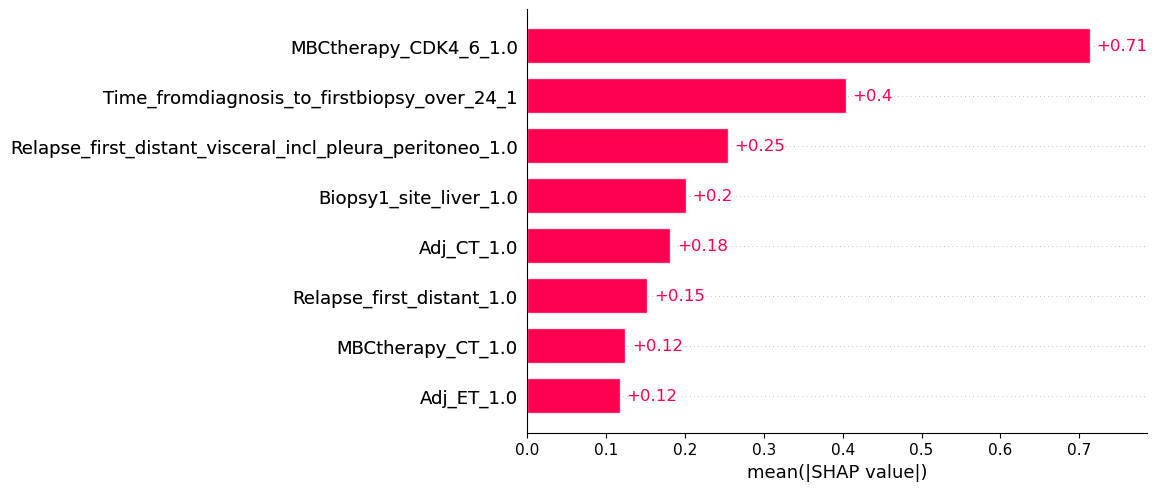

In [32]:
# Extract preprocessed and selected test data for SHAP
X_test_preprocessed = best_model.named_steps['preprocessor'].transform(X_test)
X_test_selected = best_model.named_steps['feature_selection'].transform(X_test_preprocessed)

try:
    ohe_feature_names = best_model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_vars)
    all_feature_names = np.array(numeric_vars + list(ohe_feature_names))
    selected_feature_indices = best_model.named_steps['feature_selection'].get_support(indices=True)
    surviving_features = all_feature_names[selected_feature_indices]
except Exception as e:
    surviving_features = [f"Feature_{i}" for i in range(X_test_selected.shape[1])]

# SHAP values
xgb_trained_model = best_model.named_steps['classifier']
explainer = shap.Explainer(xgb_trained_model)
shap_values = explainer(X_test_selected)
shap_values.feature_names = list(surviving_features)

# Plots
shap.plots.beeswarm(shap_values, show=True) 
fig = plt.gcf()
fig.set_size_inches(10, 6)
#plt.savefig("plot/revision/shap_beeswarm.png", dpi=300, bbox_inches="tight") 
plt.close(fig) 

shap.plots.bar(shap_values, show=True) 
fig = plt.gcf()
fig.set_size_inches(10, 6)
#plt.savefig("plot/revision/shap_bar.png", dpi=300, bbox_inches="tight") 
plt.close(fig)

## 10. Confidence Interval
From actual test labels and predictions --> bootstrap with 1000 iterations

In [33]:
y_true = np.array(y_test)
y_predictions = np.array(y_pred)

n_iterations = 1000
precisions, recalls = [], []

# Run bootstrap
for i in range(n_iterations):
    y_test_resampled, y_pred_resampled = resample(y_true, y_predictions, random_state=i)
    
    # We focus on Class 1 ("Switch")
    precisions.append(precision_score(y_test_resampled, y_pred_resampled, pos_label=1, zero_division=0))
    recalls.append(recall_score(y_test_resampled, y_pred_resampled, pos_label=1, zero_division=0))

# Calculate the 2.5th and 97.5th percentiles (95% CI)
precision_ci = (np.percentile(precisions, 2.5), np.percentile(precisions, 97.5))
recall_ci = (np.percentile(recalls, 2.5), np.percentile(recalls, 97.5))

print(f"Switch Class Precision: 0.50 (95% CI: {precision_ci[0]:.2f} - {precision_ci[1]:.2f})")
print(f"Switch Class Recall: 0.69 (95% CI: {recall_ci[0]:.2f} - {recall_ci[1]:.2f})")

Switch Class Precision: 0.50 (95% CI: 0.30 - 0.70)
Switch Class Recall: 0.69 (95% CI: 0.43 - 0.89)


## 11. Decision Curve Analysis

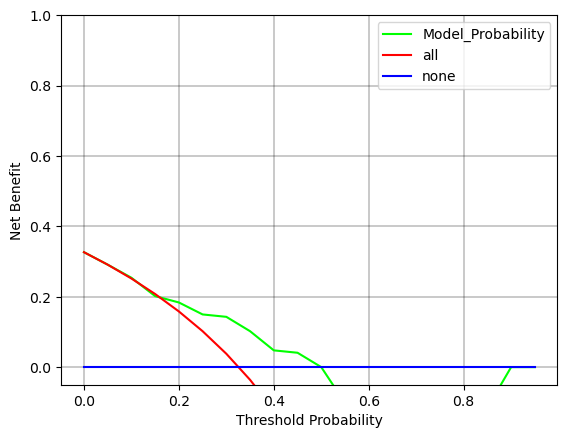

In [34]:
# Get predicted probabilities for the Switch class
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

# DCA package
dca_df = pd.DataFrame({
    'True_Switch': y_test,
    'Model_Probability': y_pred_proba
})

# Calculate DCA
dca_results = dca(
    data=dca_df,
    outcome='True_Switch',
    modelnames=['Model_Probability'],
    thresholds=np.arange(0, 1.01, 0.05) # 5% increments as granularity
)

# Plot 
plot_graphs(plot_df=dca_results, graph_type='net_benefit')
ax = plt.gca()
ax.set_xlim(0.0, 0.6)
ax.set_title("Decision Curve Analysis: Model vs Default Strategies")
ax.set_ylabel("Net Benefit")
ax.set_xlabel("Threshold Probability")
plt.tight_layout()
#plt.savefig("plot/revision/dca_net_benefit.png", dpi=300, bbox_inches="tight")
plt.close()